In [ ]:
# from google.colab import drive

# drive.mount('/content/drive')

# %cd /content/drive/MyDrive/faster_rcnn
# %cp VOC2007.zip /content
# %cp VOC2012.zip /content

In [1]:
from pathlib import Path
import zipfile

data_path = Path("data/")
data_path.mkdir(exist_ok=True)

voc2007_zip_path = Path("VOC2007.zip")
voc2012_zip_path = Path("VOC2012.zip")

if not voc2007_zip_path.exists() or not voc2012_zip_path.exists():
    raise RuntimeError("Dataset not found.")

print("Extracting 2007 dataset ...")

with zipfile.ZipFile(voc2007_zip_path, "r") as zip_ref:
    zip_ref.extractall(data_path)

print(f"Extracting 2012 dataset ...")
with zipfile.ZipFile(voc2012_zip_path, "r") as zip_ref:
    zip_ref.extractall(data_path)

Extracting 2007 dataset ...
Extracting 2012 dataset ...


In [18]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

In [19]:
from src.backbone import backbone_transform
from src.dataset import get_voc_img_paths_train, get_voc_img_paths_test, create_voc_dataloader

transform = backbone_transform

voc2007_img_paths_train, voc2012_img_paths_train = get_voc_img_paths_train()
voc2007_img_paths_test, voc2012_img_paths_test = get_voc_img_paths_test()

combined_train_img_paths = voc2007_img_paths_train + voc2012_img_paths_train

train_dataloader = create_voc_dataloader(img_paths_list=combined_train_img_paths, transform=transform, batch_size=2, shuffle=True)
test_dataloader = create_voc_dataloader(img_paths_list=voc2007_img_paths_test, transform=transform, batch_size=2, shuffle=True)

In [20]:
# from src.backbone import Backbone
# from src.rpn import RPN_Head, RegionProposalNetwork
# from src.roi import RoIPool
# from src.detection_net import DetectionHead, DetectionNet
# import torch
# from pathlib import Path

# # Step-1 RPN network: frozen, exists only to generate proposals.
# backbone_rpn = Backbone().to(device)
# rpn_head = RPN_Head(in_channels=1024, mid_channels=512)

# # rpn_checkpoint_path = Path("/content/drive/MyDrive/faster_rcnn/checkpoints/step1_epoch_10.pt")
# rpn_checkpoint_path = Path("checkpoints/step1_epoch_10.pt")
# rpn_checkpoint = torch.load(rpn_checkpoint_path, map_location=device)

# backbone_rpn.load_state_dict(rpn_checkpoint['backbone_state_dict'])
# rpn_head.load_state_dict(rpn_checkpoint['rpn_head_state_dict'])
# print(f"Loaded RPN Checkpoint: {rpn_checkpoint_path}")

# rpn_net = RegionProposalNetwork(rpn_head).to(device)

# for param in backbone_rpn.parameters():
#     param.requires_grad = False
# for param in rpn_head.parameters():
#     param.requires_grad = False

# # eval() here and never train() again
# backbone_rpn.eval()
# rpn_net.eval()

# # Step-2 detection network: separate, fresh ImageNet weights, trained.
# backbone = Backbone().to(device)
# roi_pool = RoIPool(output_size=(7, 7), pooling_mode="adaptive").to(device)
# detection_head = DetectionHead().to(device)


In [21]:
from src.backbone import Backbone
from src.rpn import RPN_Head, RegionProposalNetwork
from src.roi import RoIPool
from src.detection_net import DetectionHead, DetectionNet
import torch
from pathlib import Path

# Step-1 RPN network: frozen, exists only to generate proposals.
rpn_head = RPN_Head(in_channels=1024, mid_channels=512)

# rpn_checkpoint_path = Path("/content/drive/MyDrive/faster_rcnn/checkpoints/step1_epoch_10.pt")
rpn_checkpoint_path = Path("checkpoints/step3_epoch_10.pt")
rpn_checkpoint = torch.load(rpn_checkpoint_path, map_location=device)

# backbone checkpint_path
backbone_checkpoint_path = Path("checkpoints/step2_epoch_6.pt")
backbone_checkpoint = torch.load(backbone_checkpoint_path, map_location=device)

detection_head_checkpoint_path = Path("checkpoints/step4_epoch_6.pt")
detection_head_checkpoint = torch.load(detection_head_checkpoint_path, map_location=device)

# Step-2 detection network: separate, fresh ImageNet weights, trained.
backbone = Backbone().to(device)
roi_pool = RoIPool(output_size=(7, 7), pooling_mode="adaptive").to(device)
detection_head = DetectionHead().to(device)

rpn_head.load_state_dict(rpn_checkpoint['rpn_head_state_dict'])
print(f"Loaded RPN Checkpoint: {rpn_checkpoint_path}")

backbone.load_state_dict(backbone_checkpoint['backbone_state_dict'])
print(f"Loaded Backbone Checkpoint: {backbone_checkpoint_path}")

detection_head.load_state_dict(detection_head_checkpoint['detection_head_state_dict'])
print(f"Loaded Detection Head Checkpoint: {detection_head_checkpoint_path}")

rpn_network = RegionProposalNetwork(rpn_head=rpn_head).to(device)
detection_network = DetectionNet(detection_head=detection_head, background_label=20, delta_std=(0.1, 0.1, 0.2, 0.2)).to(device)

for param in backbone.parameters():
    param.requires_grad = False
for param in rpn_head.parameters():
    param.requires_grad = False
for param in detection_head.parameters():
    param.requires_grad = False

# eval() here and never train() again
backbone.eval()
rpn_head.eval()
rpn_network.eval()
detection_head.eval()
detection_network.eval()

Loaded RPN Checkpoint: checkpoints/step3_epoch_10.pt
Loaded Backbone Checkpoint: checkpoints/step2_epoch_6.pt
Loaded Detection Head Checkpoint: checkpoints/step4_epoch_6.pt


DetectionNet(
  (detection_head): DetectionHead(
    (conv5_x): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(1024, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(1024, 2048, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (1): Bottleneck(
        (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(

In [30]:
batch_imgs, batch_boxes, batch_labels, batch_img_sizes_before_pad = next(iter(test_dataloader))

with torch.inference_mode():
    batch_imgs = batch_imgs.to(device)
    batch_gt_boxes = [boxes.to(device) for boxes in batch_boxes]         # Not needed as the functions take care, but for safety
    batch_gt_labels = [labels.to(device) for labels in batch_labels]
    
    backbone.eval()
    rpn_head.eval()
    rpn_network.eval()
    roi_pool.eval()
    detection_head.eval()
    detection_network.eval()

    batch_feature_maps = backbone(batch_imgs)
    batch_scores, batch_proposals = rpn_network(batch_feature_maps, batch_img_height=batch_imgs.shape[2],  batch_img_width=batch_imgs.shape[3], img_sizes_before_pad=batch_img_sizes_before_pad, pre_nms_top_n=6000, post_nms_top_n=2000)
    

    print(f"batch_feature_maps.shape: {batch_feature_maps.shape}")
    pooled_batch = roi_pool(batch_feature_maps, batch_proposals, batch_imgs.shape[2], batch_imgs.shape[3])

    batch_pred_labels, batch_pred_scores, batch_pred_boxes = detection_network(batch_proposals, pooled_batch, batch_img_sizes_before_pad)


batch_feature_maps.shape: torch.Size([2, 1024, 50, 50])


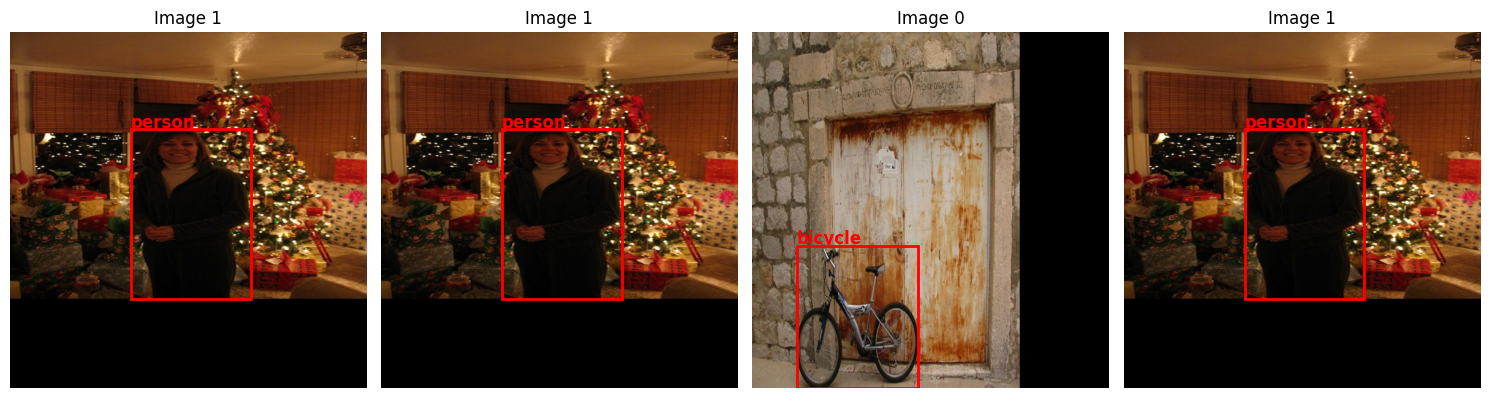

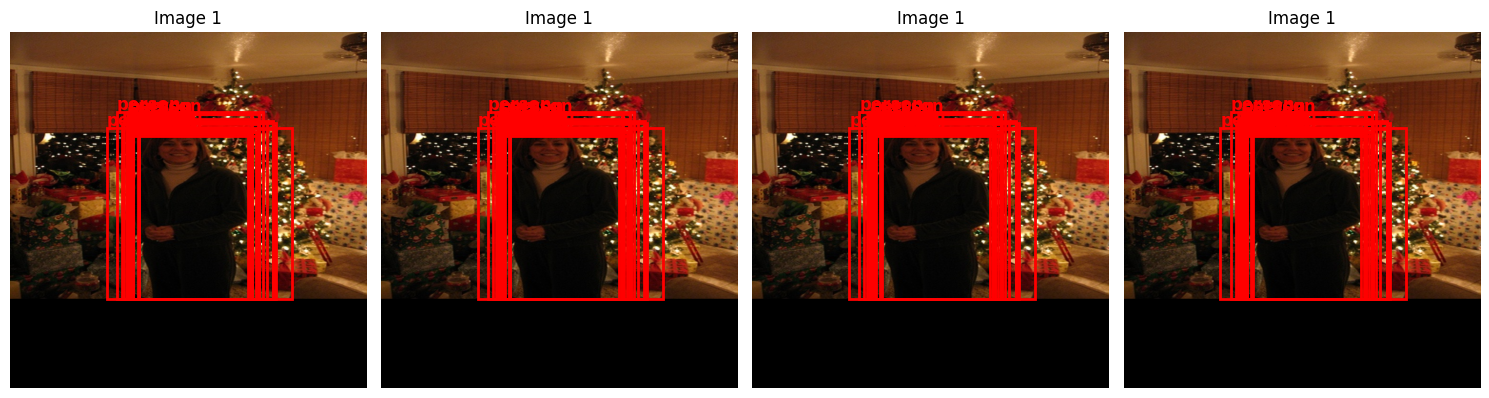

In [31]:
from src.utils import display_random_batch_images

display_random_batch_images(batch_imgs, batch_boxes, batch_labels, num_images=4)
display_random_batch_images(batch_imgs, batch_pred_boxes, batch_pred_labels, num_images=4)

In [32]:
import torchvision.ops as ops

batch_pred_boxes_nms = []
batch_pred_labels_nms = []
batch_pred_scores_nms = []

for i in range(len(batch_imgs)):
    pred_boxes = batch_pred_boxes[i]
    pred_scores = batch_pred_scores[i]
    pred_labels = batch_pred_labels[i]

    keep_idx = ops.nms(pred_boxes, pred_scores, iou_threshold=0.5)

    pred_boxes_nms = pred_boxes[keep_idx]
    pred_labels_nms = pred_labels[keep_idx]
    pred_scores_nms = pred_scores[keep_idx]

    batch_pred_boxes_nms.append(pred_boxes_nms)
    batch_pred_labels_nms.append(pred_labels_nms)
    batch_pred_scores_nms.append(pred_scores_nms)

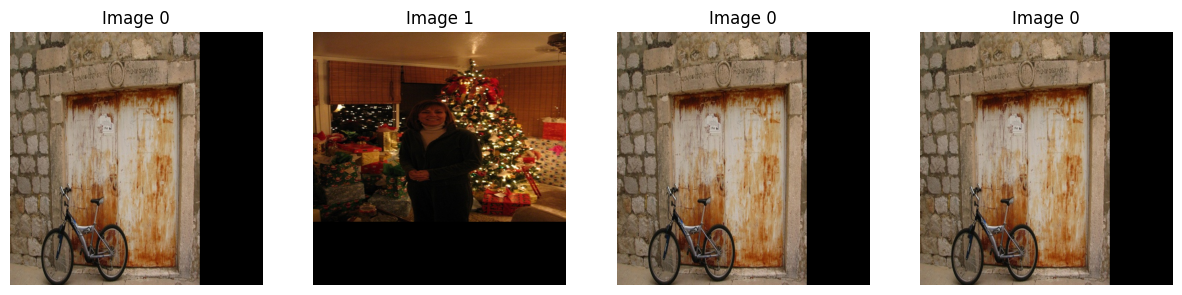

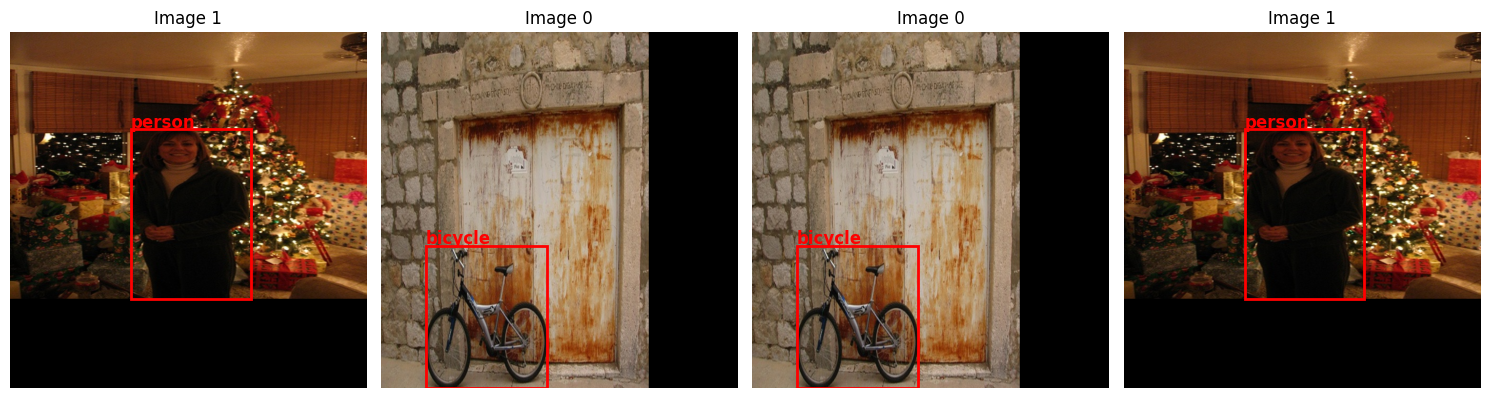

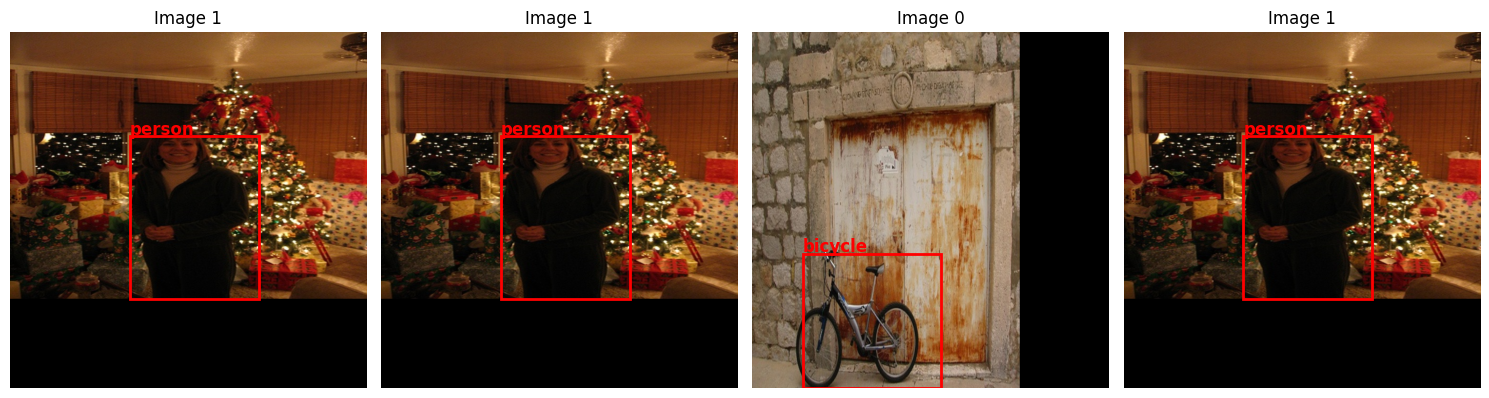

In [33]:
from src.utils import display_random_batch_images
import matplotlib.pyplot as plt
import random

num_images = 4
fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
for i in range(num_images):
    idx = random.randint(0, len(batch_imgs) - 1)
    img = batch_imgs[idx].permute(1, 2, 0).cpu().numpy()  # Convert to HWC format and move to CPU
    axes[i].imshow(img)
    axes[i].set_title(f"Image {idx}")
    axes[i].axis('off')
    
display_random_batch_images(batch_imgs, batch_boxes, batch_labels, num_images=4)
display_random_batch_images(batch_imgs, batch_pred_boxes_nms, batch_pred_labels_nms, num_images=4)